In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# ============================================================
# 1. CARREGAR SILVER SINAN + ANALISAR ATRASO DE DIGITAÇÃO
# ============================================================
arquivos = sorted(glob.glob('../data/silver/sinan/*.parquet'))
silver = pd.concat([pd.read_parquet(f) for f in arquivos], ignore_index=True)

# Converter data de notificação
silver['DT_NOTIFIC'] = pd.to_datetime(silver['DT_NOTIFIC'], errors='coerce')
silver = silver.dropna(subset=['DT_NOTIFIC'])

# Agrupar por semana epidemiológica
silver['semana'] = silver['DT_NOTIFIC'].dt.to_period('W')
casos_por_semana = (
    silver.groupby('semana')
    .size()
    .reset_index(name='casos_notificados')
)
casos_por_semana['semana_dt'] = casos_por_semana['semana'].dt.to_timestamp()

print(f"Silver carregado: {len(silver):,} registros")
print(f"Período: {silver['DT_NOTIFIC'].min().date()} → {silver['DT_NOTIFIC'].max().date()}")
print(f"Total semanas: {len(casos_por_semana)}")
print(f"\nÚltimas 8 semanas (onde o rabo de peixe aparece):")
print(casos_por_semana.tail(8).to_string(index=False))

Silver carregado: 390,048 registros
Período: 2007-01-01 → 2024-12-28
Total semanas: 939

Últimas 8 semanas (onde o rabo de peixe aparece):
               semana  casos_notificados  semana_dt
2024-11-04/2024-11-10                112 2024-11-04
2024-11-11/2024-11-17                126 2024-11-11
2024-11-18/2024-11-24                174 2024-11-18
2024-11-25/2024-12-01                202 2024-11-25
2024-12-02/2024-12-08                305 2024-12-02
2024-12-09/2024-12-15                363 2024-12-09
2024-12-16/2024-12-22                561 2024-12-16
2024-12-23/2024-12-29                453 2024-12-23


In [2]:
# ============================================================
# 2. CALCULAR FATOR DE CORREÇÃO HISTÓRICO
# ============================================================
# Ideia: para cada semana, comparar quantos casos foram 
# registrados "na época" vs quantos aparecem hoje no sistema
# Usamos o ano de digitação (ano) vs ano da notificação como proxy

silver['ano_notific'] = silver['DT_NOTIFIC'].dt.year
silver['semana_num'] = silver['DT_NOTIFIC'].dt.isocalendar().week.astype(int)

# Calcular volume por semana epidemiológica ao longo dos anos
# Para estimar o fator de correção, analisamos as últimas N semanas
# de cada ano — são as que historicamente ficam subnotificadas

# Separar dados por posição na série anual
silver['semana_do_ano'] = silver['DT_NOTIFIC'].dt.dayofyear // 7

# Calcular média de casos por semana para semanas "maduras" (anteriores a 8 semanas atrás)
# vs semanas "recentes" (últimas 8 semanas do ano)
resultados = []

for ano in range(2018, 2025):
    df_ano = casos_por_semana[
        casos_por_semana['semana_dt'].dt.year == ano
    ].copy()
    
    if len(df_ano) < 10:
        continue
    
    # Semanas maduras = todas exceto últimas 4
    maduras = df_ano.iloc[:-4]['casos_notificados'].mean()
    # Últimas 4 semanas do ano
    ultimas = df_ano.iloc[-4:]['casos_notificados'].mean()
    
    # Fator = quanto as últimas semanas representam vs média geral
    fator = maduras / ultimas if ultimas > 0 else 1.0
    
    resultados.append({
        'ano': ano,
        'media_semanas_maduras': round(maduras, 1),
        'media_ultimas_4_semanas': round(ultimas, 1),
        'fator_correcao': round(fator, 3)
    })

df_fatores = pd.DataFrame(resultados)
print("Fator de correção histórico por ano:")
print(df_fatores.to_string(index=False))
print(f"\nFator médio: {df_fatores['fator_correcao'].mean():.3f}")
print(f"Fator mediano: {df_fatores['fator_correcao'].median():.3f}")

Fator de correção histórico por ano:
 ano  media_semanas_maduras  media_ultimas_4_semanas  fator_correcao
2018                  127.0                     72.2           1.757
2019                  180.6                    369.2           0.489
2020                  641.5                    106.5           6.023
2021                  344.3                    781.2           0.441
2022                  662.4                    259.5           2.553
2023                  539.0                    241.8           2.230
2024                  784.2                    420.5           1.865

Fator médio: 2.194
Fator mediano: 1.865


In [3]:
# ============================================================
# 3. NOWCASTING — Abordagem correta por lag de digitação
# ============================================================
# Estratégia: analisar quanto tempo leva para uma notificação
# aparecer no sistema após a data do evento
# Usamos a coluna 'ano' (ano do arquivo) vs DT_NOTIFIC como proxy

# Reconstruir com informação de qual arquivo veio cada registro
dfs = []
for f in arquivos:
    ano_arquivo = int(f.split('dengue_mt_')[1].replace('.parquet', ''))
    df_temp = pd.read_parquet(f)
    df_temp['ano_arquivo'] = ano_arquivo
    dfs.append(df_temp)

silver_lag = pd.concat(dfs, ignore_index=True)
silver_lag['DT_NOTIFIC'] = pd.to_datetime(silver_lag['DT_NOTIFIC'], errors='coerce')
silver_lag = silver_lag.dropna(subset=['DT_NOTIFIC'])
silver_lag['ano_notific'] = silver_lag['DT_NOTIFIC'].dt.year

# Calcular lag: registros do ano X que vieram em arquivos do ano X+1, X+2...
silver_lag['lag_anos'] = silver_lag['ano_arquivo'] - silver_lag['ano_notific']

print("Distribuição do lag de digitação (anos):")
print(silver_lag['lag_anos'].value_counts().sort_index())

# Percentual de casos por lag
total = len(silver_lag)
print(f"\nPercentual acumulado:")
for lag in range(0, 4):
    pct = (silver_lag['lag_anos'] <= lag).sum() / total * 100
    print(f"  Até {lag} ano(s) de atraso: {pct:.1f}%")

Distribuição do lag de digitação (anos):
lag_anos
-1       140
 0    389552
 1       356
Name: count, dtype: int64

Percentual acumulado:
  Até 0 ano(s) de atraso: 99.9%
  Até 1 ano(s) de atraso: 100.0%
  Até 2 ano(s) de atraso: 100.0%
  Até 3 ano(s) de atraso: 100.0%


Completude e fator de correção por semana epidemiológica:
 semana_epi  completude_media  fator_nowcasting
         42          0.882134          1.133615
         43          0.887145          1.127211
         44          0.892336          1.120654
         45          0.899796          1.111363
         46          0.906739          1.102853
         47          0.916696          1.090875
         48          0.930131          1.075117
         49          0.946308          1.056738
         50          0.966142          1.035044
         51          0.984709          1.015528
         52          0.999382          1.000619
         53          1.000000          1.000000


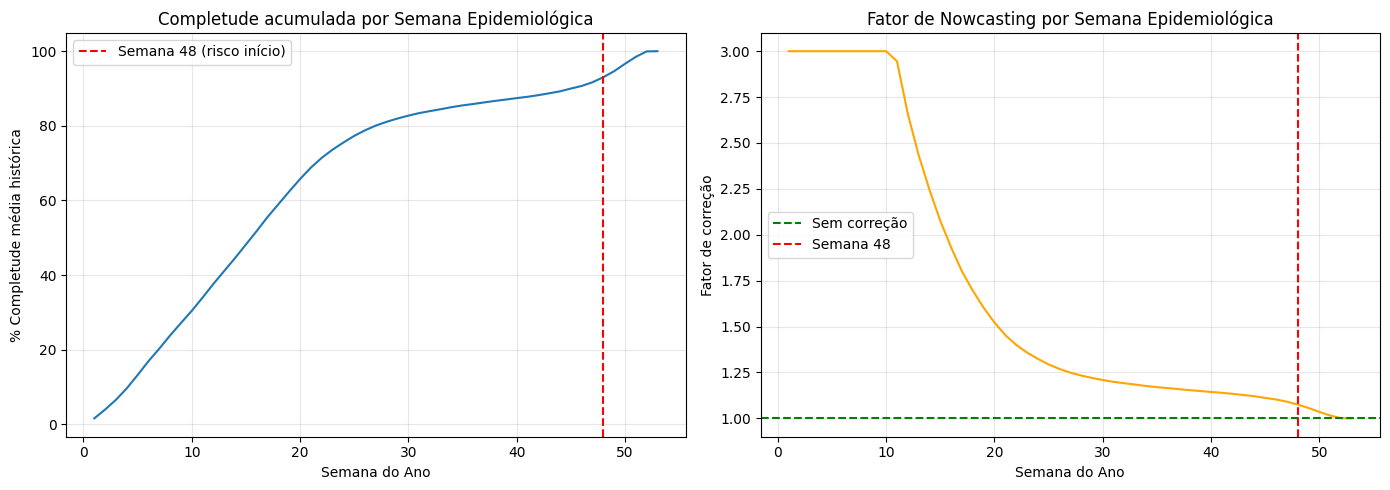


Figura salva!


In [4]:
# ============================================================
# 4. FATOR DE COMPLETUDE POR SEMANA DO ANO
# ============================================================
# Como 99.9% dos dados são do mesmo ano, o atraso é intra-anual
# Vamos calcular: para cada semana epidemiológica (1-53),
# qual o percentual de completude histórica?

silver['DT_NOTIFIC'] = pd.to_datetime(silver['DT_NOTIFIC'], errors='coerce')
silver['semana_epi'] = silver['DT_NOTIFIC'].dt.isocalendar().week.astype(int)
silver['ano_notific'] = silver['DT_NOTIFIC'].dt.year

# Casos por semana epidemiológica × ano
casos_semana_ano = (
    silver[silver['ano_notific'].between(2018, 2023)]  # anos completos
    .groupby(['ano_notific', 'semana_epi'])
    .size()
    .reset_index(name='casos')
)

# Para cada ano, calcular o total anual e o percentual acumulado por semana
fatores = []
for ano in range(2018, 2024):
    df_ano = casos_semana_ano[casos_semana_ano['ano_notific'] == ano].copy()
    total_ano = df_ano['casos'].sum()
    df_ano = df_ano.sort_values('semana_epi')
    df_ano['pct_acumulado'] = df_ano['casos'].cumsum() / total_ano
    df_ano['pct_semana'] = df_ano['casos'] / total_ano
    fatores.append(df_ano)

df_fatores = pd.concat(fatores)

# Média do percentual por semana epidemiológica (across anos)
completude = (
    df_fatores.groupby('semana_epi')['pct_acumulado']
    .mean()
    .reset_index(name='completude_media')
)

# Fator de correção = 1 / completude esperada até aquela semana
completude['fator_nowcasting'] = (1 / completude['completude_media']).clip(upper=3.0)

print("Completude e fator de correção por semana epidemiológica:")
print(completude.tail(12).to_string(index=False))

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(completude['semana_epi'], completude['completude_media'] * 100)
ax1.set_title('Completude acumulada por Semana Epidemiológica')
ax1.set_xlabel('Semana do Ano')
ax1.set_ylabel('% Completude média histórica')
ax1.axvline(x=48, color='red', linestyle='--', label='Semana 48 (risco início)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(completude['semana_epi'], completude['fator_nowcasting'], color='orange')
ax2.set_title('Fator de Nowcasting por Semana Epidemiológica')
ax2.set_xlabel('Semana do Ano')
ax2.set_ylabel('Fator de correção')
ax2.axhline(y=1.0, color='green', linestyle='--', label='Sem correção')
ax2.axvline(x=48, color='red', linestyle='--', label='Semana 48')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/fig_nowcasting_fator.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigura salva!")

In [5]:
# ============================================================
# 5. SALVAR FATOR E APLICAR NO DATASET
# ============================================================
from pathlib import Path

# Salvar tabela de fatores
completude.to_parquet('../data/external/nowcasting_fatores.parquet', index=False)
print("Fatores salvos em data/external/nowcasting_fatores.parquet")

# Carregar gold dataset_features_v2
df_gold = pd.read_parquet('../data/gold/dataset_features_v2.parquet')
print(f"\nGold carregado: {df_gold.shape}")
print(f"Colunas disponíveis: {df_gold.columns.tolist()[:10]}...")

# Verificar se tem coluna de data ou semana
cols_data = [c for c in df_gold.columns if 'data' in c.lower() or 'date' in c.lower() or 'semana' in c.lower()]
print(f"\nColunas de data/semana: {cols_data}")
print(f"\nPrimeiras linhas:")
print(df_gold.head(3).to_string())

Fatores salvos em data/external/nowcasting_fatores.parquet

Gold carregado: (2242, 55)
Colunas disponíveis: ['data', 'casos', 'precipitacao_total', 'temp_media', 'temp_max', 'temp_min', 'umidade_media', 'umidade_max', 'umidade_min', 'ano']...

Colunas de data/semana: ['data', 'semana_ano', 'semana_seno', 'semana_cosseno']

Primeiras linhas:
        data  casos  precipitacao_total  temp_media  temp_max  temp_min  umidade_media  umidade_max  umidade_min   ano  mes  semana_ano  dia_ano  trimestre  mes_seno  mes_cosseno  semana_seno  semana_cosseno  casos_lag_7d  casos_lag_14d  casos_lag_21d  casos_lag_28d  casos_mm_7d  casos_mm_14d  casos_mm_28d  precip_lag_28d  umidade_lag_28d  temp_lag_28d  precip_lag_35d  umidade_lag_35d  temp_lag_35d  precip_lag_42d  umidade_lag_42d  temp_lag_42d  precip_mm_7d  umidade_mm_7d  precip_mm_14d  umidade_mm_14d  precip_mm_28d  umidade_mm_28d  amplitude_termica  precip_acum_7d  precip_acum_14d  precip_acum_28d  dias_sem_chuva    ndvi     ndwi  anos_desde_pic

In [6]:
# ============================================================
# 6. APLICAR NOWCASTING + ADICIONAR FEATURES DA SEMANA 7
# ============================================================

df_v3 = df_gold.copy()
df_v3['data'] = pd.to_datetime(df_v3['data'])

# --- Feature 1: Nowcasting ---
# Merge pelo número da semana do ano
df_v3 = df_v3.merge(
    completude[['semana_epi', 'fator_nowcasting']],
    left_on='semana_ano',
    right_on='semana_epi',
    how='left'
).drop(columns='semana_epi')

# Casos corrigidos pelo fator
df_v3['casos_nowcast'] = (df_v3['casos'] * df_v3['fator_nowcasting']).round(1)

# --- Feature 2: municipio_id ---
# Cuiabá = 5103403, Várzea Grande = 5108402
# Dataset atual é só Cuiabá/VG agregado — usar flag sazonal como proxy
# Adicionamos como constante por ora (será expandido no v_multi_municipio)
df_v3['municipio_id'] = 5103403  # Cuiabá — expandir na Semana 8

# --- Feature 3: normalização por 100k hab ---
# Pop Cuiabá 2022: 632.481 hab
POP_CUIABA = 632481
df_v3['casos_por_100k'] = (df_v3['casos'] / POP_CUIABA * 100000).round(4)
df_v3['casos_nowcast_por_100k'] = (df_v3['casos_nowcast'] / POP_CUIABA * 100000).round(4)

# --- Diagnóstico ---
print(f"dataset_features_v3: {df_v3.shape}")
print(f"Features novas adicionadas: fator_nowcasting, casos_nowcast, municipio_id, casos_por_100k, casos_nowcast_por_100k")
print(f"\nNovas features — amostra semanas críticas (jan/fev):")
cols_diag = ['data', 'semana_ano', 'casos', 'fator_nowcasting', 'casos_nowcast', 'casos_por_100k']
print(df_v3[df_v3['semana_ano'] <= 8][cols_diag].head(10).to_string(index=False))

print(f"\nComparação casos raw vs nowcast (últimas 4 semanas do ano):")
print(df_v3[df_v3['semana_ano'] >= 49][cols_diag].tail(8).to_string(index=False))

dataset_features_v3: (2242, 60)
Features novas adicionadas: fator_nowcasting, casos_nowcast, municipio_id, casos_por_100k, casos_nowcast_por_100k

Novas features — amostra semanas críticas (jan/fev):
      data  semana_ano  casos  fator_nowcasting  casos_nowcast  casos_por_100k
2018-02-12           7     24               3.0           72.0          3.7946
2018-02-13           7     27               3.0           81.0          4.2689
2018-02-14           7     38               3.0          114.0          6.0081
2018-02-15           7     37               3.0          111.0          5.8500
2018-02-16           7     32               3.0           96.0          5.0594
2018-02-17           7     29               3.0           87.0          4.5851
2018-02-18           7     16               3.0           48.0          2.5297
2018-02-19           8     55               3.0          165.0          8.6959
2018-02-20           8     63               3.0          189.0          9.9608
2018-02-21

In [7]:
# ============================================================
# 7. SALVAR DATASET_FEATURES_V3
# ============================================================
from pathlib import Path

# Salvar Gold v3
Path('../data/gold').mkdir(parents=True, exist_ok=True)
df_v3.to_parquet('../data/gold/dataset_features_v3.parquet', index=False)

print(f"dataset_features_v3 salvo!")
print(f"   Shape: {df_v3.shape} ({df_v3.shape[1]} features)")
print(f"   Período: {df_v3['data'].min().date()} → {df_v3['data'].max().date()}")
print(f"\nFeatures v2 → v3:")
print(f"   v2: 55 features")
print(f"   v3: {df_v3.shape[1]} features (+{df_v3.shape[1]-55} novas)")
print(f"\nNovas features:")
novas = ['fator_nowcasting', 'casos_nowcast', 'municipio_id', 
         'casos_por_100k', 'casos_nowcast_por_100k']
for f in novas:
    print(f"   + {f}")

dataset_features_v3 salvo!
   Shape: (2242, 60) (60 features)
   Período: 2018-02-12 → 2024-12-28

Features v2 → v3:
   v2: 55 features
   v3: 60 features (+5 novas)

Novas features:
   + fator_nowcasting
   + casos_nowcast
   + municipio_id
   + casos_por_100k
   + casos_nowcast_por_100k
